# LanguageIdentification_HyperdimensionalVectors

Magnus H

This experiment applies hyperdimensional computing to language identification.
Sentences from 20 European languages are encoded as 10,000-dimensional bipolar vectors, and language centroids are formed as digital “fingerprints.”

New sentences are classified by comparing vector similarity to these centroids, reaching about 76.8% accuracy — showing that even simple high-dimensional representations can distinguish languages effectively.

Processed 300 per languages
10000 dimentions
*   Accuracy: 0.765
*   F1-Score: 0.754


1000 dimentions and trigram



*   Accuracy: 0.725
*   F1-Score: 0.712


Model is based on the paper ***Distributed Representation of n-gram statistics for Boosting Self-Organizing Maps with Hyperdimensional Computing***



Working with 26 letters and a whitespace that makes it 27 and we use tri-grams so its 27^3

When dealing with operations in higher dimentions we can expect higher computational cost. Another issue might if we only use small n-grams we might not manage to capture long term relationships in the text. Im not sure about how typos affects the reslut but it also might do that.

In [ ]:
!pip install unidecode
# Libraries
import zipfile
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from unidecode import unidecode
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score


# Paths
training_input_dir = '/content/trainfolder/'
training_output_dir = '/content/train_preprocessed/'

testing_input_dir = '/content/testfolder/'
testing_output_dir = '/content/test_preprocessed/'


## Step: Preprocessing
This part of the pipeline reads specific files and executes a cleaning operation.

* Remove numbers non-alphanumeric characters
* Converts characters like ö to o etc to fit our selected symbols
* Coverts everything into lowercase
* and finally remove extra white space

We also init the symbols "abcdefghijklmnopqrstuvwxyz " (note the whitespace)


In [ ]:
symbols = list("abcdefghijklmnopqrstuvwxyz ")

def preprocess_sentences(file_path, line_limit=None):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            sentences = f.readlines()

        if line_limit:
            sentences = sentences[:line_limit]

        cleaned_sentences = []
        for sentence in sentences:
            original_sentence = sentence.strip()
            cleaned_sentence = re.sub(r'[^\w\s]', '', re.sub(r'\d+', '', unidecode(original_sentence).lower()))
            if cleaned_sentence.strip():
                cleaned_sentences.append(cleaned_sentence)

        return cleaned_sentences

    except Exception:
        return []

def preprocess_all_languages(input_dir, output_dir, line_limit=None):
    os.makedirs(output_dir, exist_ok=True)

    for file_name in os.listdir(input_dir):
        input_path = os.path.join(input_dir, file_name)
        output_path = os.path.join(output_dir, f"{file_name}_preprocessed.txt")
        cleaned_sentences = preprocess_sentences(input_path, line_limit)

        # Save cleaned sentences to the output directory
        if cleaned_sentences:
            with open(output_path, 'w', encoding='utf-8') as f:
                f.writelines('\n'.join(cleaned_sentences))


## Generation of bipolar vectors

***generate_bipolar_vectors*** creates a dictionary that maps each symbol to a high-dimensional bipolar vector

In [ ]:
def generate_bipolar_vectors(symbols, vector_size):

    symbol_vectors = {}
    for symbol in symbols:
        vector = np.random.choice([-1, 1], size=vector_size) # generates a random bipolar vector
        symbol_vectors[symbol] = vector
    return symbol_vectors

## Encoding engrams
The ***encode_engram*** is encoding an n-gram into a single, high-dimensional vector using the the pre-generated bipolar vectors for individual symbols.

In [ ]:
def encode_engram(engram, symbol_vectors):
    try:
        encoded_vector = symbol_vectors[engram[0]]
    except KeyError:
        return np.zeros_like(next(iter(symbol_vectors.values())))

    for symbol in engram[1:]:
        if symbol in symbol_vectors:
            encoded_vector = np.multiply(encoded_vector, symbol_vectors[symbol])

    norm = np.linalg.norm(encoded_vector)
    normalized_vector = encoded_vector / norm if norm != 0 else encoded_vector

    return normalized_vector

## Encoding sentence
***encode_sentence*** is like the bridge between character encoding  and sentence representation.

In [ ]:
def encode_sentence(sentence, symbol_vectors, n):
    ngrams = [sentence[i:i+n] for i in range(len(sentence) - n + 1)]
    encoded_sentence = np.zeros_like(list(symbol_vectors.values())[0], dtype=np.float64)

    for ngram in ngrams:
        encoded_ngram = encode_engram(ngram, symbol_vectors)
        encoded_sentence += encoded_ngram

    norm = np.linalg.norm(encoded_sentence)
    return encoded_sentence / norm if norm != 0 else encoded_sentence

## Cosine similarity
The ***cosine_similarity***
 calculate the similarity between two vectors using the cosine angle between them.

In [ ]:
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    # We dont want devide by zero
    if norm1 != 0 and norm2 != 0:
        similarity = dot_product / (norm1 * norm2)
    else:
        similarity = 0.0

    return similarity

## Build centroids
***Compute_language_centroids*** calculates a centroid for each language based the aggregated sentences for that language

In [ ]:
def compute_language_centroids(train_dir, symbol_vectors):
    centroids = {}

    for file_name in os.listdir(train_dir):
        # Extract language code from the filename
        language = file_name.split('_')[0]

        file_path = os.path.join(train_dir, file_name)
        print(f"Calculating centroid for {language} from {file_name}")

        aggregated_vector = np.zeros_like(list(symbol_vectors.values())[0], dtype=np.float64)
        with open(file_path, 'r', encoding='utf-8') as f:
            for sentence in f:
                # Trigram
                trigrams = [sentence[i:i+3] for i in range(len(sentence) - 3 + 1)]
                encoded_sentence = np.zeros_like(aggregated_vector)

                for trigram in trigrams:
                    encoded_sentence += encode_engram(trigram, symbol_vectors)

                aggregated_vector += encoded_sentence

        # Normalize the aggregated vector
        norm = np.linalg.norm(aggregated_vector)
        centroids[language] = aggregated_vector / norm if norm != 0 else aggregated_vector

        print(f"Centroid calculated for {language}")
    return centroids



## Classification
***classify_text*** returns the predicted language centroid it is most similar to in the set.

In [ ]:
def classify_text(query_text, centroids, symbol_vectors, n):

    query_vector = np.zeros_like(list(symbol_vectors.values())[0], dtype=np.float64)

    # Encode the query text
    for i in range(len(query_text) - n + 1):
        ngram = query_text[i:i+n]
        query_vector += encode_engram(ngram, symbol_vectors)

    # Normalize the
    query_vector /= np.linalg.norm(query_vector) if np.linalg.norm(query_vector) != 0 else 1

    # Compare with centroids
    similarities = {
        language: cosine_similarity(query_vector, centroid)
        for language, centroid in centroids.items()
    }
    predicted_language = max(similarities, key=similarities.get)
    #print(f"Predicted language: {predicted_language}, Similarities: {similarities}")
    return predicted_language


## Evaluation part



In [ ]:
def evaluate_model(test_dir, centroids, symbol_vectors, line_limit=300):
    true_labels = []
    predicted_labels = []

    expected_languages = list(centroids.keys())  # Languages we expect based on centroids
    print("Starting testing...")

    for file_name in os.listdir(test_dir):
        # Get language filename
        language_match = re.search(r'europarl-v7\.([a-z]{2})-en\.[a-z]{2}_preprocessed\.txt', file_name)
        if not language_match:
            print(f"Could not extract language code from: {file_name}")
            continue

        language = language_match.group(1)  # language code
        if language not in expected_languages:
            print(f"Error finding file")
            continue

        file_path = os.path.join(test_dir, file_name)
        line_count = 0  #  counter

        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if line_count >= line_limit:
                    break  # Reaching the line limit

                query_vector = np.zeros_like(list(symbol_vectors.values())[0], dtype=np.float64)

                # Trigram
                trigrams = [line[i:i+3] for i in range(len(line) - 3 + 1)]
                for trigram in trigrams:
                    query_vector += encode_engram(trigram, symbol_vectors)

                # Normalize
                query_vector /= np.linalg.norm(query_vector) if np.linalg.norm(query_vector) != 0 else 1

                # cosine similarity centroids
                similarities = {
                    lang: cosine_similarity(query_vector, centroid)
                    for lang, centroid in centroids.items()
                }
                predicted_language = max(similarities, key=similarities.get)

                true_labels.append(language)
                predicted_labels.append(predicted_language)
                line_count += 1

        print(f"Processed {line_count} lines for: {language}")

    # labels for confusion matrix
    filtered_labels = [label for label in expected_languages if label in set(true_labels)]
    print(f"Labels used for confusion matrix: {filtered_labels}")

    # error check
    if not filtered_labels:
        print("Error no labels.")
        return

    # confusion matrix, accuracy, and F1-score
    conf_matrix = confusion_matrix(true_labels, predicted_labels, labels=filtered_labels)
    accuracy = accuracy_score(true_labels, predicted_labels)
    f1 = f1_score(true_labels, predicted_labels, average='weighted')

    print("\nConfusion Matrix:\n", conf_matrix)
    print("\nAccuracy:", accuracy)
    print("\nF1-Score:", f1)

    # confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', xticklabels=filtered_labels, yticklabels=filtered_labels)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()


## Running the pipeline



Running with 10000 dimentions
Preprocessing training data...
Preprocessing testing data...
Getting the centroids based in the training.
Calculating centroid for fr from fr_sentences.txt_preprocessed.txt
Centroid calculated for fr
Calculating centroid for lv from lv_sentences.txt_preprocessed.txt
Centroid calculated for lv
Calculating centroid for es from es_sentences.txt_preprocessed.txt
Centroid calculated for es
Calculating centroid for it from it_sentences.txt_preprocessed.txt
Centroid calculated for it
Calculating centroid for sk from sk_sentences.txt_preprocessed.txt
Centroid calculated for sk
Calculating centroid for sv from sv_sentences.txt_preprocessed.txt
Centroid calculated for sv
Calculating centroid for bg from bg_sentences.txt_preprocessed.txt
Centroid calculated for bg
Calculating centroid for pt from pt_sentences.txt_preprocessed.txt
Centroid calculated for pt
Calculating centroid for fi from fi_sentences.txt_preprocessed.txt
Centroid calculated for fi
Calculating centro

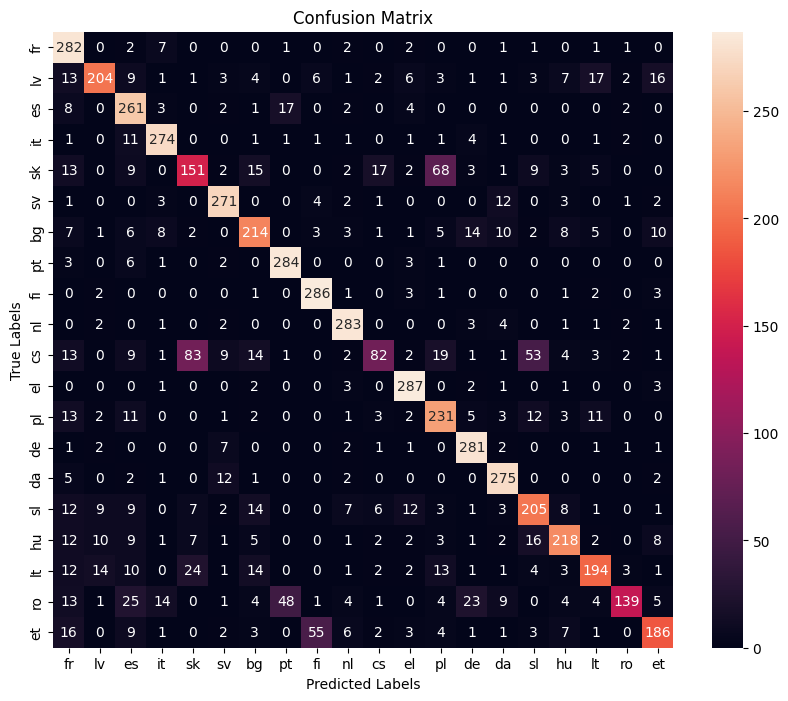

In [ ]:
# Preprocess training data
vector_size = 10000  # dimensions are set here
print(f"Running with {vector_size} dimentions")
print("Preprocessing training data...")
preprocess_all_languages(training_input_dir, training_output_dir, line_limit=9000) #

# Preprocess testing data
print("Preprocessing testing data...")
preprocess_all_languages(testing_input_dir, testing_output_dir, line_limit=2000)    #


symbol_vectors = generate_bipolar_vectors(symbols, vector_size)

# Compute centroids
print("Getting the centroids based in the training.")
centroids = compute_language_centroids(training_output_dir, symbol_vectors)    # trigram

# Evaluate model
print("Evaluating classifier")
evaluate_model(testing_output_dir, centroids, symbol_vectors)




10000 dimentions and trigram
Accuracy: 0.7648333333333334

F1-Score: 0.7541977906445142

1000 dimentions and trigram
Accuracy: 0.7248333333333333

F1-Score: 0.7119705000000751